In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# **Elementy odstające (*ang. outliers*)**

**Elementy odstające** to punkty danych znalazujące się w znacznej odległości od grupy innych punktów - byty wyróżniające się z tłumu.

Problemy spowodowane outliersami:

* Długi czas uczenia modelu predykcyjnego
* Kiepska dokładność predykcji
* Zwiększenie błędu wariancji
* Zmniejszenie normalności rozkładu danych
* Osłabienie mocy testów statystycznych

## Typy elementów odstających

**1. OUTLIERSY JEDNOWYMIAROWE**

  * Występują w rozkładach opisujących jedną zmienną
  
  * Przykład: wynagrodzenia pracowników w jednej firmie
  
  * Łatwo widoczne na histogramach i wykresach pudełkowych

**2. OUTLIERSY WIELOWYMIAROWE**

 * Znajdują się w przestrzeniach n-wymiarowych

 * Przykład: dane klientów (wiek, dochód, wydatki)

 * Trudniejsze do wykrycia bez specjalnych metod

# **Metody wykrywania elementów odstających**

### **Metoda 1**: Wykres pudełkowy


* Tworzy podział punktów ze względu na kwartyle (Q1, Q2, Q3)

* Dane między Q1 a Q3 umieszczane w prostokątnych pudełkach

* Elementy odstające wyświetlane jako pojedyncze punkty poza pudełkiem

* Pokazuje rozstęp ćwiartkowy (IQR)

**Zalety**:

* Wizualna reprezentacja

* Szybkie zidentyfikowanie outliersów

* Porównanie wielu zmiennych



### **Metoda 2**: Wykres punktowy

* Wyświetla punkty na dwuwymiarowym układzie współrzędnych
* Jedna zmienna na osi X, druga na osi Y
* Idealny do wizualizacji relacji między dwoma zmiennymi
* Anomalie widoczne jako izolowane punkty daleko od klastera

**Zalety**:

* Łatwa identyfikacja outlierów wielowymiarowych
* Wizualna analiza trendów
* Pokazuje korelacje między zmiennymi

### **Metoda 3**: Wynik standaryzowany Z-score
**Formuła:**

z = (x - μ) / σ

Gdzie:

x = wartość danych,
μ = średnia (mean),
σ = odchylenie standardowe (standard deviation)

**Reguła**:

|z| > 3 → element odstający (99.7% danych powinno mieć |z| ≤ 3)

|z| > 2.5 → potencjalny outlier

**Założenia:**

* Rozkład normalny danych

* Metoda parametryczna

### **Metoda 4**: Rozstęp ćwiartkowy (IQR)
**Formuła:**
  IQR = Q3 - Q1

Gdzie: Q1 = pierwszy kwartyl (25. percentyl), Q3 = trzeci kwartyl (75. percentyl)

**Zasada outliersów**:

* Dolny limit: Q1 - 1.5 × IQR

* Górny limit: Q3 + 1.5 × IQR

* Wartości poza limitami = outliersy

**Zalety**:

* Odporna miara (mało wrażliwa na ekstrema)
* Nie wymaga założenia o rozkładzie normalnym
* Metoda nieparametryczna



### **Metoda 5**: Percentyl

**Percentyl** dzieli dane na 100 grup o równych rozmiarach. Wartość percentyla określa procent populacji znajdujący się poniżej tej wartości.

**Przykłady**:

* 1. percentyl: bardzo niskie wartości
* 50. percentyl: mediana
* 99. percentyl: bardzo wysokie wartości



**Reguła outliersów**:

* Wartości poniżej 1. percentyla → outliersy niskie
* Wartości powyżej 99. percentyla → outliersy wysokie
* Można również użyć 5. i 95. percentyla

## **PODSUMOWANIE**

1. **CO TO OUTLIER?**
   
   Punkt danych daleko od głównej grupy, wyróżniający się z tłumu

2. **DLACZEGO WAŻNY?**
   
   Psuje modele, zmniejsza dokładność, zwiększa błąd

3. **METODY WYKRYWANIA:**

    * Boxplot (wykres pudełkowy)

    * Scatter plot (wykres punktowy)

    * Z-score (standaryzacja)

    * IQR (rozstęp ćwiartkowy)

    * Percentyle

4. **KLUCZOWE TERMINY:**
Q1, Q3, IQR, σ (sigma), μ (mu), z-score, outlier

## **Przykład praktyczny**

**Dane**:
Wynagrodzenia pracowników (tys. zł): 2.5, 2.8, 3.0, 3.2, 3.5, 4.0, 4.2, 4.5, 5.0, 15.0


In [ ]:
# Dane: wynagrodzenia (tys. zł)
dane = np.array([2.5, 2.8, 3.0, 3.2, 3.5, 4.0, 4.2, 4.5, 5.0, 15.0])
print("\n1. DANE TESTOWE:")
print(f"   Wynagrodzenia: {dane}")
print(f"   Liczba obserwacji: {len(dane)}")


1. DANE TESTOWE:
   Wynagrodzenia: [ 2.5  2.8  3.   3.2  3.5  4.   4.2  4.5  5.  15. ]
   Liczba obserwacji: 10


In [ ]:
print("\n" + "="*60)
print("METODA 1: WYKRES PUDEŁKOWY (BOXPLOT - IQR)")
print("="*60)

Q1 = np.percentile(dane, 25)
Q3 = np.percentile(dane, 75)
IQR = Q3 - Q1
dolny_limit = Q1 - 1.5 * IQR
gorny_limit = Q3 + 1.5 * IQR

print(f"\nQ1 (25. percentyl) = {Q1:.2f}")
print(f"Q3 (75. percentyl) = {Q3:.2f}")
print(f"IQR = Q3 - Q1 = {IQR:.2f}")
print(f"\nLimity dla outliersów:")
print(f"  Dolny limit = Q1 - 1.5 × IQR = {Q1:.2f} - 1.5 × {IQR:.2f} = {dolny_limit:.2f}")
print(f"  Górny limit = Q3 + 1.5 × IQR = {Q3:.2f} + 1.5 × {IQR:.2f} = {gorny_limit:.2f}")

outliersy_iqr = dane[(dane < dolny_limit) | (dane > gorny_limit)]
print(f"\n✓ OUTLIERSY WYKRYTE (metoda IQR): {outliersy_iqr}")


METODA 1: WYKRES PUDEŁKOWY (BOXPLOT - IQR)

Q1 (25. percentyl) = 3.05
Q3 (75. percentyl) = 4.42
IQR = Q3 - Q1 = 1.38

Limity dla outliersów:
  Dolny limit = Q1 - 1.5 × IQR = 3.05 - 1.5 × 1.38 = 0.99
  Górny limit = Q3 + 1.5 × IQR = 4.42 + 1.5 × 1.38 = 6.49

✓ OUTLIERSY WYKRYTE (metoda IQR): [15.]


In [ ]:
print("\n" + "="*60)
print("METODA 2: Z-SCORE")
print("="*60)

srednia = np.mean(dane)
std_dev = np.std(dane, ddof=1)  # ddof=1 dla próby
z_scores = np.abs(stats.zscore(dane))

print(f"\nŚrednia (μ) = {srednia:.2f}")
print(f"Odchylenie standardowe (σ) = {std_dev:.2f}")
print(f"\nFormuła: z = (x - μ) / σ")
print(f"\nZ-score dla każdej wartości:")

for i, (wartosc, z) in enumerate(zip(dane, z_scores)):
    status = "⚠️ OUTLIER" if z > 3 else ""
    print(f"  {wartosc:5.1f} → z = {z:6.2f} {status}")

outliersy_z = dane[z_scores > 3]
print(f"\n✓ OUTLIERSY WYKRYTE (z > 3): {outliersy_z}")


METODA 2: Z-SCORE

Średnia (μ) = 4.77
Odchylenie standardowe (σ) = 3.68

Formuła: z = (x - μ) / σ

Z-score dla każdej wartości:
    2.5 → z =   0.65 
    2.8 → z =   0.56 
    3.0 → z =   0.51 
    3.2 → z =   0.45 
    3.5 → z =   0.36 
    4.0 → z =   0.22 
    4.2 → z =   0.16 
    4.5 → z =   0.08 
    5.0 → z =   0.07 
   15.0 → z =   2.93 

✓ OUTLIERSY WYKRYTE (z > 3): []


In [ ]:
print("\n" + "="*60)
print("METODA 3: PERCENTYL")
print("="*60)

p1 = np.percentile(dane, 1)
p99 = np.percentile(dane, 99)
p5 = np.percentile(dane, 5)
p95 = np.percentile(dane, 95)

print(f"\n1. percentyl = {p1:.2f}")
print(f"5. percentyl = {p5:.2f}")
print(f"95. percentyl = {p95:.2f}")
print(f"99. percentyl = {p99:.2f}")

print(f"\nOutliersy poniżej 1. percentyla: {dane[dane < p1]}")
print(f"Outliersy powyżej 99. percentyla: {dane[dane > p99]}")


METODA 3: PERCENTYL


NameError: name 'dane' is not defined

In [ ]:
print("\n" + "="*60)
print("PODSUMOWANIE - PORÓWNANIE METOD")
print("="*60)

print(f"\n{'Metoda':<25} {'Wykryte outliersy':<30} {'Liczba'}")
print("-" * 60)
print(f"{'IQR':<25} {str(outliersy_iqr):<30} {len(outliersy_iqr)}")
print(f"{'Z-score (|z| > 3)':<25} {str(outliersy_z):<30} {len(outliersy_z)}")
print(f"{'Percentyl (1-99%)':<25} {str(dane[(dane < p1) | (dane > p99)]):<30} {len(dane[(dane < p1) | (dane > p99)])}")


PODSUMOWANIE - PORÓWNANIE METOD

Metoda                    Wykryte outliersy              Liczba
------------------------------------------------------------
IQR                       [15.]                          1
Z-score (|z| > 3)         []                             0
Percentyl (1-99%)         [ 2.5 15. ]                    2


In [ ]:
print("\n" + "="*60)
print("PRZYKŁAD 2: DANE WIELOWYMIAROWE")
print("="*60)

dane_2d = np.array([
    [25, 30000],  # wiek, dochód (tys. zł)
    [27, 32000],
    [26, 31000],
    [28, 33000],
    [30, 35000],
    [28, 250000],  # ← OUTLIER!
])

df = pd.DataFrame(dane_2d, columns=['Wiek', 'Dochód'])
print("\nDane klientów (Wiek, Dochód w tys. zł):")
print(df.to_string(index=False))

# Z-score dla każdej kolumny
z_scores_wiek = np.abs(stats.zscore(df['Wiek']))
z_scores_dochod = np.abs(stats.zscore(df['Dochód']))

outliersy_2d = df[(z_scores_wiek > 2) | (z_scores_dochod > 2)]
print(f"\n✓ OUTLIERSY WIELOWYMIAROWE (z > 2 dla dowolnej zmiennej):")
print(outliersy_2d.to_string())



PRZYKŁAD 2: DANE WIELOWYMIAROWE

Dane klientów (Wiek, Dochód w tys. zł):
 Wiek  Dochód
   25   30000
   27   32000
   26   31000
   28   33000
   30   35000
   28  250000

✓ OUTLIERSY WIELOWYMIAROWE (z > 2 dla dowolnej zmiennej):
   Wiek  Dochód
5    28  250000


## Wizualizacja analizy

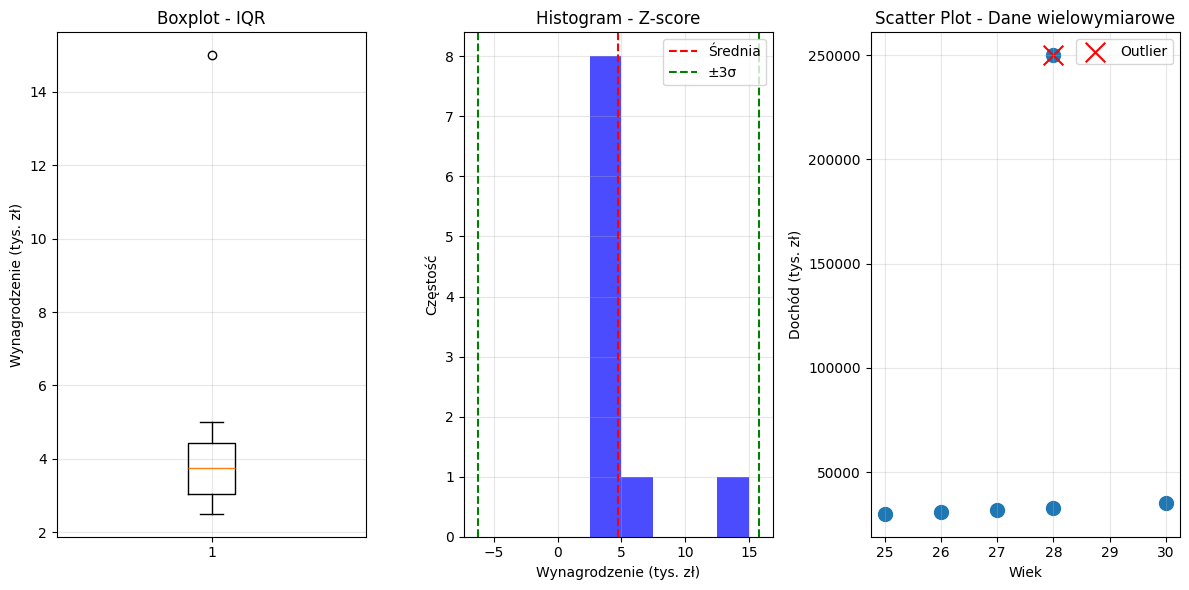

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.boxplot(dane)
plt.ylabel('Wynagrodzenie (tys. zł)')
plt.title('Boxplot - IQR')
plt.grid(True, alpha=0.3)

# Histogram z Z-score
plt.subplot(1, 3, 2)
plt.hist(dane, bins=5, alpha=0.7, color='blue')
plt.axvline(srednia, color='red', linestyle='--', label='Średnia')
plt.axvline(srednia + 3*std_dev, color='green', linestyle='--', label='±3σ')
plt.axvline(srednia - 3*std_dev, color='green', linestyle='--')
plt.xlabel('Wynagrodzenie (tys. zł)')
plt.ylabel('Częstość')
plt.title('Histogram - Z-score')
plt.legend()
plt.grid(True, alpha=0.3)

# Scatter plot 2D
plt.subplot(1, 3, 3)
plt.scatter(dane_2d[:, 0], dane_2d[:, 1], s=100)
plt.scatter(dane_2d[-1, 0], dane_2d[-1, 1], color='red', s=200, marker='x', label='Outlier')
plt.xlabel('Wiek')
plt.ylabel('Dochód (tys. zł)')
plt.title('Scatter Plot - Dane wielowymiarowe')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# **Zadanie 1**


Pracujesz w firmie zajmującej się e-commerce. Otrzymałeś dane o sprzedaży
dziennej (liczba sztuk) z ostatnich 30 dni.


ZADANIE:
- Wczytaj dane sprzedażowe
- Zrób wizualizację danych
- Zastosuj metodę IQR, z-score oraz opartą na percentylach (1-99%)
- Zidentyfikuj outliersów
- Wyjaśnij co mogło się stać



In [2]:
from google.colab import files
uploaded = files.upload()

Saving sprzedaz_dzienna.csv to sprzedaz_dzienna.csv


In [3]:
df = pd.read_csv("sprzedaz_dzienna.csv")
df.head(10)

,Unnamed: 0,dzien,sprzedaz,dzien_tygodnia
0,0,1,65,Pn
1,1,2,71,Wt
2,2,3,69,Sr
3,3,4,73,Cz
4,4,5,74,Pt
5,5,6,44,Sb
6,6,7,41,Nd
7,7,8,71,Pn
8,8,9,72,Wt
9,9,10,70,Sr


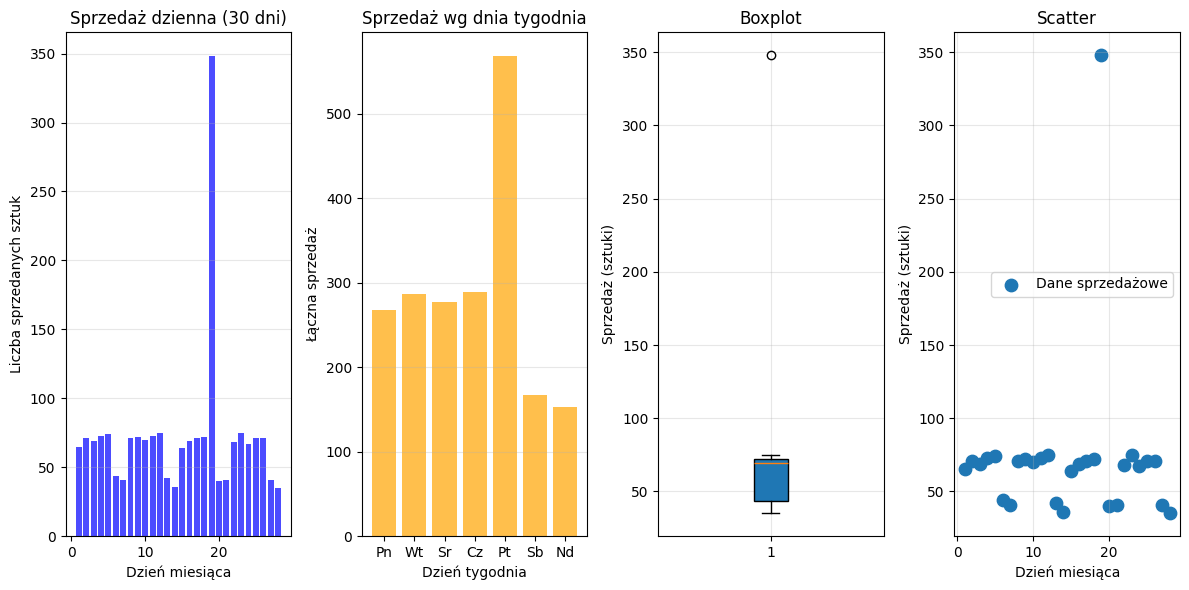

In [4]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.bar(df['dzien'], df['sprzedaz'], color='blue', alpha=0.7)
plt.xlabel('Dzień miesiąca')
plt.ylabel('Liczba sprzedanych sztuk')
plt.title('Sprzedaż dzienna (30 dni)')
plt.grid(True, axis='y', alpha=0.3)

days = ['Pn', 'Wt', 'Sr', 'Cz', 'Pt', 'Sb', 'Nd']
sales_by_day = df.groupby('dzien_tygodnia')['sprzedaz'].sum()
sales_ordered = sales_by_day.reindex(days)

plt.subplot(1, 4, 2)
plt.bar(days, sales_ordered, color='orange', alpha=0.7)
plt.xlabel('Dzień tygodnia')
plt.ylabel('Łączna sprzedaż')
plt.title('Sprzedaż wg dnia tygodnia')
plt.grid(True, axis='y', alpha=0.3)

plt.subplot(1, 4, 3)
plt.boxplot(df['sprzedaz'], vert=True, patch_artist=True)
plt.ylabel('Sprzedaż (sztuki)')
plt.title('Boxplot')
plt.grid(True, alpha=0.3)

plt.subplot(1, 4, 4)
plt.scatter(df['dzien'], df['sprzedaz'], label='Dane sprzedażowe', s=80)
plt.xlabel('Dzień miesiąca')
plt.ylabel('Sprzedaż (sztuki)')
plt.title('Scatter')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# IQR
Q1 = np.percentile(df['sprzedaz'], 25)
Q3 = np.percentile(df['sprzedaz'], 75)
IQR = Q3 - Q1
dolny_limit = Q1 - 1.5 * IQR
gorny_limit = Q3 + 1.5 * IQR

print(f"\nQ1 (25. percentyl) = {Q1:.2f}")
print(f"Q3 (75. percentyl) = {Q3:.2f}")
print(f"IQR = Q3 - Q1 = {IQR:.2f}")
print(f"\nLimity dla outliersów:")
print(f"  Dolny limit = Q1 - 1.5 × IQR = {Q1:.2f} - 1.5 × {IQR:.2f} = {dolny_limit:.2f}")
print(f"  Górny limit = Q3 + 1.5 × IQR = {Q3:.2f} + 1.5 × {IQR:.2f} = {gorny_limit:.2f}")

outliersy_iqr = df[(df['sprzedaz'] < dolny_limit) | (df['sprzedaz'] > gorny_limit)]
print("\n✓ OUTLIERSY WYKRYTE (metoda IQR)")
display(outliersy_iqr)


Q1 (25. percentyl) = 43.50
Q3 (75. percentyl) = 72.00
IQR = Q3 - Q1 = 28.50

Limity dla outliersów:
  Dolny limit = Q1 - 1.5 × IQR = 43.50 - 1.5 × 28.50 = 0.75
  Górny limit = Q3 + 1.5 × IQR = 72.00 + 1.5 × 28.50 = 114.75

✓ OUTLIERSY WYKRYTE (metoda IQR)


,Unnamed: 0,dzien,sprzedaz,dzien_tygodnia
18,18,19,348,Pt


In [6]:
# Z-SCORE
srednia = np.mean(df['sprzedaz'])
std_dev = np.std(df['sprzedaz'], ddof=1)
z_scores = np.abs(stats.zscore(df['sprzedaz']))

print(f"\nŚrednia (μ) = {srednia:.2f}")
print(f"Odchylenie standardowe (σ) = {std_dev:.2f}")
print(f"\nFormuła: z = (x - μ) / σ")
print(f"\nZ-score dla każdej wartości:")

for i, (wartosc, z) in enumerate(zip(df['sprzedaz'], z_scores)):
    status = "⚠️ OUTLIER" if z > 3 else ""
    print(f"  {wartosc:5.1f} → z = {z:6.2f} {status}")

outliersy_z = df[z_scores > 3]
print("\n✓ OUTLIERSY WYKRYTE (z > 3)")
display(outliersy_z)


Średnia (μ) = 71.75
Odchylenie standardowe (σ) = 55.99

Formuła: z = (x - μ) / σ

Z-score dla każdej wartości:
   65.0 → z =   0.12 
   71.0 → z =   0.01 
   69.0 → z =   0.05 
   73.0 → z =   0.02 
   74.0 → z =   0.04 
   44.0 → z =   0.50 
   41.0 → z =   0.56 
   71.0 → z =   0.01 
   72.0 → z =   0.00 
   70.0 → z =   0.03 
   73.0 → z =   0.02 
   75.0 → z =   0.06 
   42.0 → z =   0.54 
   36.0 → z =   0.65 
   64.0 → z =   0.14 
   69.0 → z =   0.05 
   71.0 → z =   0.01 
   72.0 → z =   0.00 
  348.0 → z =   5.02 ⚠️ OUTLIER
   40.0 → z =   0.58 
   41.0 → z =   0.56 
   68.0 → z =   0.07 
   75.0 → z =   0.06 
   67.0 → z =   0.09 
   71.0 → z =   0.01 
   71.0 → z =   0.01 
   41.0 → z =   0.56 
   35.0 → z =   0.67 

✓ OUTLIERSY WYKRYTE (z > 3)


,Unnamed: 0,dzien,sprzedaz,dzien_tygodnia
18,18,19,348,Pt


In [7]:
# PERCENTYL
p1 = np.percentile(df['sprzedaz'], 1)
p99 = np.percentile(df['sprzedaz'], 99)
p5 = np.percentile(df['sprzedaz'], 5)
p95 = np.percentile(df['sprzedaz'], 95)

print(f"\n1. percentyl = {p1:.2f}")
print(f"5. percentyl = {p5:.2f}")
print(f"95. percentyl = {p95:.2f}")
print(f"99. percentyl = {p99:.2f}")

print(f"\nOutliersy poniżej 1. percentyla")
display(df[df['sprzedaz'] < p1])
print(f"Outliersy powyżej 99. percentyla")
display(df[df['sprzedaz'] > p99])


1. percentyl = 35.27
5. percentyl = 37.40
95. percentyl = 75.00
99. percentyl = 274.29

Outliersy poniżej 1. percentyla


,Unnamed: 0,dzien,sprzedaz,dzien_tygodnia
27,27,28,35,Nd


Outliersy powyżej 99. percentyla


,Unnamed: 0,dzien,sprzedaz,dzien_tygodnia
18,18,19,348,Pt


Najwyższy odczyt wystąpił 19 dnia i jest outlierem we wszystkich metodach.Znaleziony outliers dodatni może wynikać np. z wystąpienia dużej promocji czy też błędu ludzkiego.

W przypadku ujemnych dotyczą one szczególnie dni wolnych (co widać na scatterze). Dodatkowo metoda oparta na percentylach wskazała najniższą wartość w dniu 28, który to jest właśnie weekendem.

## **Zadanie 2**

Jesteś analitykiem w banku. Otrzymałeś dane o klientach zaciągających kredyty.
Każdy klient ma 4 cechy:
  1. Wiek (lata)
  2. Dochód roczny (tys. PLN)
  3. Suma kredytów (tys. PLN)
  4. Liczba lat jako klient

Do zrobienia:
- Zidentyfikować klientów wielowymiarowych outliersów
- Użyj metody z-score dla każdego wymiaru osobno



In [37]:
from google.colab import files
uploaded = files.upload()

Saving klienci_banku.csv to klienci_banku (1).csv


In [38]:
df2 = pd.read_csv("klienci_banku.csv")
df2.head(10)

,Unnamed: 0,wiek_lat,dochod_roczny_tys,suma_kredytow_tys,lata_jako_klient
0,0,53.18,80.63,65.34,12.99
1,1,41.28,75.23,218.69,3.96
2,2,48.89,87.45,145.27,2.99
3,3,43.44,64.46,212.89,7.93
4,4,46.16,91.39,71.28,9.25
5,5,52.14,111.65,121.03,8.00
6,6,35.18,78.82,151.26,1.90
7,7,70.11,89.03,153.35,7.83
8,8,32.93,94.80,128.50,4.19
9,9,30.43,72.98,182.14,10.11


In [39]:
def analiza_z_score(df, kolumna):
    print(f"\n==== Analiza kolumny: {kolumna} ====")

    srednia = np.mean(df[kolumna])
    std_dev = np.std(df[kolumna], ddof=1)
    z_scores = np.abs(stats.zscore(df[kolumna]))

    print(f"\nŚrednia (μ) = {srednia:.2f}")
    print(f"Odchylenie standardowe (σ) = {std_dev:.2f}")
    print(f"\nFormuła: z = (x - μ) / σ")
    print(f"\nZ-score dla każdej wartości:")

    for wartosc, z in zip(df[kolumna], z_scores):
        status = "⚠️ OUTLIER" if z > 3 else ""
        print(f"  {wartosc:5.1f} → z = {z:6.2f} {status}")

    outliersy_z = df[z_scores > 3]
    print(f"\n✓ OUTLIERY DLA KOLUMNY {kolumna}:")
    display(outliersy_z)

    return (np.abs(stats.zscore(df[kolumna])) > 3)

In [40]:
o1 = analiza_z_score(df2, 'wiek_lat')
o2 = analiza_z_score(df2, 'dochod_roczny_tys')
o3 = analiza_z_score(df2, 'suma_kredytow_tys')
o4 = analiza_z_score(df2, 'lata_jako_klient')


==== Analiza kolumny: wiek_lat ====

Średnia (μ) = 62.07
Odchylenie standardowe (σ) = 135.67

Formuła: z = (x - μ) / σ

Z-score dla każdej wartości:
   53.2 → z =   0.07 
   41.3 → z =   0.15 
   48.9 → z =   0.10 
   43.4 → z =   0.14 
   46.2 → z =   0.12 
   52.1 → z =   0.07 
   35.2 → z =   0.20 
   70.1 → z =   0.06 
   32.9 → z =   0.22 
   30.4 → z =   0.24 
   58.9 → z =   0.02 
   54.5 → z =   0.06 
   52.5 → z =   0.07 
   52.5 → z =   0.07 
   44.9 → z =   0.13 
   34.2 → z =   0.21 
   45.9 → z =   0.12 
   36.9 → z =   0.19 
   56.7 → z =   0.04 
   43.2 → z =   0.14 
   35.1 → z =   0.20 
   41.1 → z =   0.16 
   50.0 → z =   0.09 
   38.2 → z =   0.18 
   35.1 → z =   0.20 
   47.9 → z =   0.11 
   47.9 → z =   0.11 
   38.9 → z =   0.17 
   39.4 → z =   0.17 
   47.8 → z =   0.11 
   27.6 → z =   0.26 
   28.1 → z =   0.25 
   36.4 → z =   0.19 
   42.4 → z =   0.15 
   48.7 → z =   0.10 
   62.7 → z =   0.00 
   55.3 → z =   0.05 
   43.1 → z =   0.14 
   44.8 → z = 

,Unnamed: 0,wiek_lat,dochod_roczny_tys,suma_kredytow_tys,lata_jako_klient
48,48,999.0,5001.0,10001.0,100.1



==== Analiza kolumny: dochod_roczny_tys ====

Średnia (μ) = 189.84
Odchylenie standardowe (σ) = 696.03

Formuła: z = (x - μ) / σ

Z-score dla każdej wartości:
   80.6 → z =   0.16 
   75.2 → z =   0.17 
   87.5 → z =   0.15 
   64.5 → z =   0.18 
   91.4 → z =   0.14 
  111.7 → z =   0.11 
   78.8 → z =   0.16 
   89.0 → z =   0.15 
   94.8 → z =   0.14 
   73.0 → z =   0.17 
   85.5 → z =   0.15 
   81.2 → z =   0.16 
   83.0 → z =   0.16 
   65.5 → z =   0.18 
   81.5 → z =   0.16 
   91.0 → z =   0.14 
  110.0 → z =   0.12 
  100.2 → z =   0.13 
  124.1 → z =   0.10 
   65.7 → z =   0.18 
   98.5 → z =   0.13 
   84.7 → z =   0.15 
  124.8 → z =   0.09 
   64.8 → z =   0.18 
   64.2 → z =   0.18 
   69.0 → z =   0.18 
   38.5 → z =   0.22 
   70.5 → z =   0.17 
   65.8 → z =   0.18 
   84.0 → z =   0.15 
   87.8 → z =   0.15 
  118.5 → z =   0.10 
  100.0 → z =   0.13 
   69.5 → z =   0.17 
   63.0 → z =   0.18 
   90.8 → z =   0.14 
   54.6 → z =   0.20 
  117.6 → z =   0.10 
  10

,Unnamed: 0,wiek_lat,dochod_roczny_tys,suma_kredytow_tys,lata_jako_klient
48,48,999.0,5001.0,10001.0,100.1



==== Analiza kolumny: suma_kredytow_tys ====

Średnia (μ) = 380.82
Odchylenie standardowe (σ) = 1391.47

Formuła: z = (x - μ) / σ

Z-score dla każdej wartości:
   65.3 → z =   0.23 
  218.7 → z =   0.12 
  145.3 → z =   0.17 
  212.9 → z =   0.12 
   71.3 → z =   0.22 
  121.0 → z =   0.19 
  151.3 → z =   0.17 
  153.3 → z =   0.17 
  128.5 → z =   0.18 
  182.1 → z =   0.14 
   97.6 → z =   0.21 
  143.9 → z =   0.17 
  157.0 → z =   0.16 
  176.7 → z =   0.15 
  186.6 → z =   0.14 
   94.8 → z =   0.21 
   74.3 → z =   0.22 
  214.9 → z =   0.12 
  167.6 → z =   0.15 
  113.6 → z =   0.19 
  228.6 → z =   0.11 
  156.8 → z =   0.16 
  210.0 → z =   0.12 
  154.4 → z =   0.16 
  254.0 → z =   0.09 
  238.8 → z =   0.10 
  138.6 → z =   0.18 
  199.6 → z =   0.13 
  183.3 → z =   0.14 
  219.4 → z =   0.12 
  102.8 → z =   0.20 
  185.3 → z =   0.14 
  203.9 → z =   0.13 
   63.1 → z =   0.23 
   91.8 → z =   0.21 
   49.0 → z =   0.24 
  137.5 → z =   0.18 
  186.9 → z =   0.14 
  2

,Unnamed: 0,wiek_lat,dochod_roczny_tys,suma_kredytow_tys,lata_jako_klient
48,48,999.0,5001.0,10001.0,100.1



==== Analiza kolumny: lata_jako_klient ====

Średnia (μ) = 9.83
Odchylenie standardowe (σ) = 13.94

Formuła: z = (x - μ) / σ

Z-score dla każdej wartości:
   13.0 → z =   0.23 
    4.0 → z =   0.43 
    3.0 → z =   0.50 
    7.9 → z =   0.14 
    9.2 → z =   0.04 
    8.0 → z =   0.13 
    1.9 → z =   0.57 
    7.8 → z =   0.14 
    4.2 → z =   0.41 
   10.1 → z =   0.02 
    9.2 → z =   0.05 
    5.3 → z =   0.33 
    6.6 → z =   0.24 
    4.9 → z =   0.36 
    7.9 → z =   0.14 
   11.0 → z =   0.08 
    5.1 → z =   0.34 
    9.6 → z =   0.02 
    6.5 → z =   0.24 
    5.7 → z =   0.30 
    7.8 → z =   0.15 
    5.0 → z =   0.35 
    6.4 → z =   0.25 
    4.5 → z =   0.39 
   14.0 → z =   0.30 
    8.2 → z =   0.12 
    6.0 → z =   0.28 
    8.7 → z =   0.08 
    7.8 → z =   0.15 
    7.4 → z =   0.17 
    9.9 → z =   0.01 
   10.4 → z =   0.04 
    6.5 → z =   0.24 
    6.4 → z =   0.25 
    7.3 → z =   0.19 
    1.2 → z =   0.63 
    3.5 → z =   0.45 
   12.2 → z =   0.17 
   13.0 

,Unnamed: 0,wiek_lat,dochod_roczny_tys,suma_kredytow_tys,lata_jako_klient
48,48,999.0,5001.0,10001.0,100.1


In [42]:
outliersy_maska = o1 | o2 | o3 | o4
outliersy_wielowymiar = df2[outliersy_maska]

print("\n===== OUTLIERY WIELOWYMIAROWE =====")
display(outliersy_wielowymiar)


===== OUTLIERY WIELOWYMIAROWE =====


,Unnamed: 0,wiek_lat,dochod_roczny_tys,suma_kredytow_tys,lata_jako_klient
48,48,999.0,5001.0,10001.0,100.1
